In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import sys
import os
import matplotlib.pyplot as plt

# Subimos un nivel en el árbol de directorios ("..") y lo añadimos al path
path_raiz = os.path.abspath("..")
if path_raiz not in sys.path:
    sys.path.append(path_raiz)

from utils.plots import plot_decision_regions
from models.LinearNeuron import Perceptron, AdalineGD, AdalineSGD

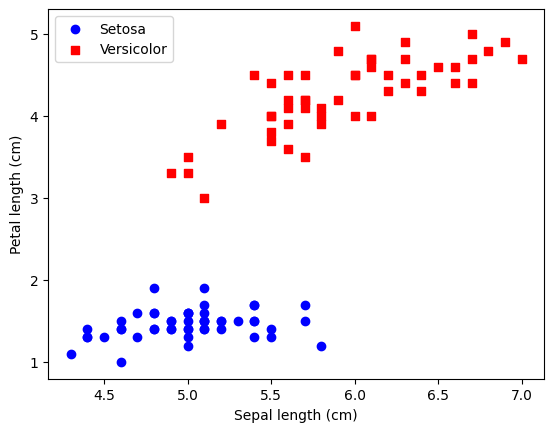

In [3]:
# Loading data
data, target = load_iris(return_X_y=True, as_frame=True)
X = data.loc[0:99,['sepal length (cm)','petal length (cm)']].values
y = target[:100].values

# Plotting clases
plt.scatter(x=X[:50,0], y=X[:50,1], c='blue', marker='o', label='Setosa')
plt.scatter(x=X[50:100,0], y=X[50:100,1], c='red', marker='s', label='Versicolor')
plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.legend(loc='upper left')
plt.show()

# Perceptron

**1. Error Calculation**
The error is calculated by comparing the true target value with the predicted target value. This difference dictates how the model should adjust itself to learn:

$$Error = y^{(i)} - \hat{y}^{(i)}$$

**2. Learning Rule (Computing Deltas)**
The perceptron learning rule defines how the update values ("deltas") are computed based on that prediction error. For an instance $i$, the update for each weight $w_j$ and the bias unit $b$ is calculated as follows:

$$\Delta w_j = \eta(y^{(i)} - \hat{y}^{(i)})x_j^{(i)}$$
$$\Delta b = \eta(y^{(i)} - \hat{y}^{(i)})$$

Where $\eta$ is the learning rate, $y^{(i)}$ is the true class label (real target), $\hat{y}^{(i)}$ is the predicted class label (predicted target) by the model, and $x_j^{(i)}$ is the input feature value.

**3. Activation Function (Decision Function)**
To determine the predicted class $\hat{y}^{(i)}$, the algorithm uses a variant of the **unit step function**. If the net input $z$ of a particular example $x^{(i)}$ is greater than or equal to a defined threshold $\theta$, the model predicts class 1; otherwise, it predicts class 0:

$$\sigma(z) = \begin{cases} 1 & \text{if } z \ge \theta \\ 0 & \text{otherwise} \end{cases}$$

**4. Updating Weights in Each Dataset Instance**
Once the error, the deltas, and the class prediction are computed, the simultaneous update of the bias unit and each weight $w_j$ in the weight vector $\boldsymbol{w}$ is performed. This operation can be formally written for each iteration as:

$$w_j := w_j + \Delta w_j$$
$$b := b + \Delta b$$

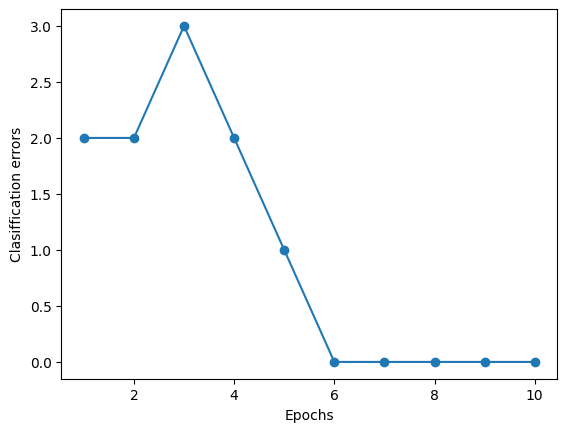

In [4]:
# Training and erros vs epochs
my_perceptron = Perceptron(eta=0.1, epochs=10)
my_perceptron.fit(X, y)
plt.plot(range(1, len(my_perceptron.errors_)+1), my_perceptron.errors_, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Clasiffication errors")
plt.show()

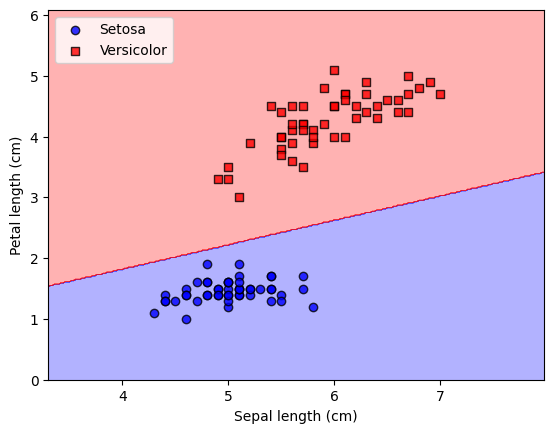

In [5]:
plot_decision_regions(X=X, y=y, algorithm=my_perceptron)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Petal length (cm)")
plt.legend(loc='upper left')
plt.show()

# Adaline

**1. Linear Activation Function**
The key difference between the Adaline rule and Rosenblatt’s perceptron is that the weights are updated based on a linear activation function rather than a unit step function. In Adaline, this linear activation function, $\sigma(z)$, is simply the identity function of the net input, so that $\sigma(z) = z$.

**2. Loss Function and Gradient Descent Optimization**
One of the key ingredients of supervised machine learning algorithms is a defined objective function that is to be optimized during the learning process. This objective function is often a loss or cost function that we want to minimize. In the case of Adaline, we can define the loss function, $L$, to learn the model parameters as the **mean squared error (MSE)** between the calculated outcome (the activation function) and the true class label:

$$L(\boldsymbol{w}, b) = \frac{1}{2n} \sum_{i=1}^{n} (y^{(i)} - \sigma(z^{(i)}))^2$$

To minimize this function, we use gradient descent. We can update the model parameters by taking a step in the opposite direction of the gradient, $\nabla L(\boldsymbol{w}, b)$, of our loss function, $L(\boldsymbol{w}, b)$. The parameter changes, $\Delta\boldsymbol{w}$ and $\Delta b$, are defined as the negative gradient multiplied by the learning rate, $\eta$:

$$\Delta\boldsymbol{w} = -\eta\nabla_{\boldsymbol{w}}L(\boldsymbol{w}, b)$$
$$\Delta b = -\eta\nabla_b L(\boldsymbol{w}, b)$$

Updating the weights simultaneously as follows:

$$\boldsymbol{w} := \boldsymbol{w} + \Delta\boldsymbol{w}$$
$$b := b + \Delta b$$

**3. Vectorized Implementation (Full Batch Gradient Descent)**
Unlike algorithms that update weights sample by sample, the Adaline cost function is evaluated over the entire training dataset at once. This full batch nature becomes evident when we look at the partial derivative of the MSE loss function with respect to the $j$th weight:

$$\frac{\partial L}{\partial w_j} = -\frac{2}{n} \sum_{i} (y^{(i)} - \sigma(z^{(i)})) x_j^{(i)}$$

Because the gradient calculation requires the summation ($\sum_i$) of the errors multiplied by the feature values across **all** instances $i$ in the dataset, the weights are only updated after evaluating the entire batch. This characteristic allows the implementation to heavily leverage matrix operations. Since the error calculations and gradient updates are computed for the whole dataset simultaneously, they can be entirely vectorized, making the training process computationally highly efficient.

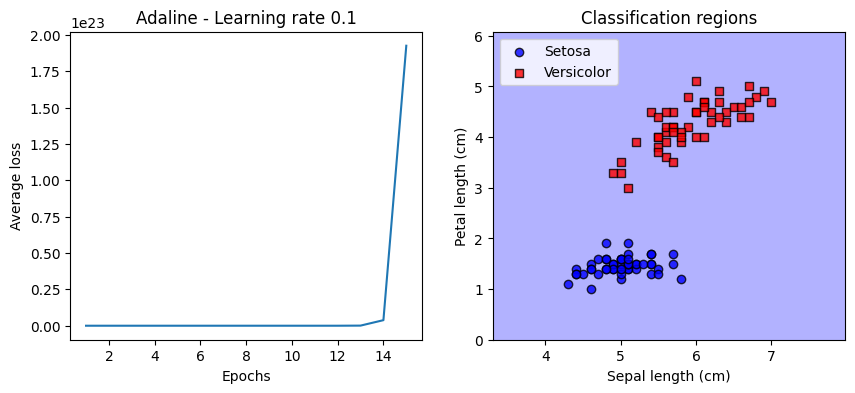

In [6]:
my_adaline = AdalineGD(eta=0.1, epochs=15)
my_adaline.fit(X,y)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(1,len(my_adaline.losses_)+1), my_adaline.losses_)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Average loss")
ax[0].set_title("Adaline - Learning rate 0.1")

plot_decision_regions(X, y, my_adaline)
ax[1].set_xlabel("Sepal length (cm)")
ax[1].set_ylabel("Petal length (cm)")
ax[1].set_title("Classification regions")
ax[1].legend(loc="upper left")
plt.show()

## Feature scaling

Feature scaling is a critical preprocessing step for the optimal performance of many machine learning algorithms, especially those that, like Adaline, rely on **gradient descent**.

**Why is it important?**
Its main benefit is that it helps gradient descent learning to **converge more quickly**. When features are on different scales, the loss function surface becomes asymmetrical, causing the optimization to take a longer, oscillating path toward the minimum. By scaling, the algorithm finds the solution more directly and efficiently.



**Standardization**
One of the most widely used methods for feature scaling is standardization. This normalization procedure shifts the mean of each feature so that it is centered at zero and each feature has a standard deviation of 1 (unit variance). 

For instance, to standardize the $j$th feature, we can simply subtract the sample mean, $\mu_j$, from every training example and divide it by its standard deviation, $\sigma_j$:

$$x'_j=\frac{x_j-\mu_j}{\sigma_j}$$

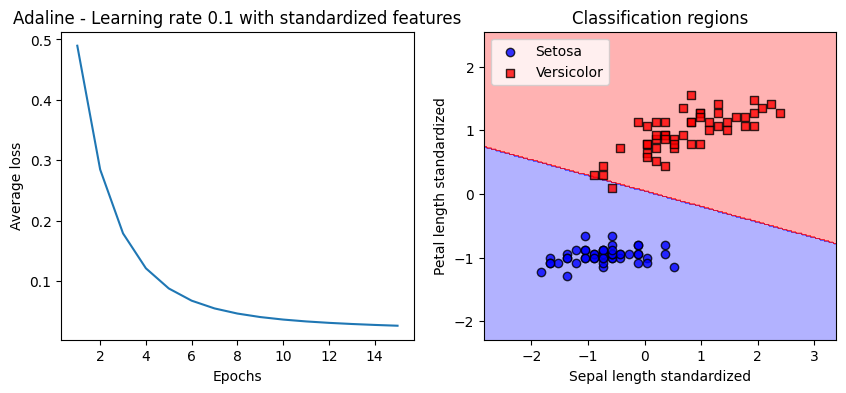

In [7]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean())/X[:,1].std()

my_adaline = AdalineGD(eta=0.1, epochs=15)
my_adaline.fit(X_std,y)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(1,len(my_adaline.losses_)+1), my_adaline.losses_)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Average loss")
ax[0].set_title("Adaline - Learning rate 0.1 with standardized features")

plot_decision_regions(X=X_std, y=y, algorithm=my_adaline)
ax[1].set_xlabel("Sepal length standardized")
ax[1].set_ylabel("Petal length standardized")
ax[1].legend(loc="upper left")
ax[1].set_title("Classification regions")
plt.show()

## Adaline Stochastic

**1. The Limitation of Full Batch Gradient Descent**
In the standard Adaline model (*full batch*), the loss gradient is calculated from the whole training dataset to take a single step toward the global minimum. In machine learning applications with millions of data points, reevaluating the entire dataset each time we take one step can be computationally quite costly.

**2. Implementation of Stochastic Gradient Descent (SGD)**
As an efficient alternative, SGD (sometimes also called iterative or online gradient descent) changes the update rule. Instead of updating the weights based on the sum of the accumulated errors over all training examples ($\sum$), it **updates the parameters incrementally for each individual training example** ($x^{(i)}$):

$$\Delta w_j = \eta(y^{(i)} - \sigma(z^{(i)}))x_j^{(i)}$$
$$\Delta b = \eta(y^{(i)} - \sigma(z^{(i)}))$$

By adjusting the weights sample by sample, the algorithm updates the model much more frequently, which often results in significantly faster convergence on large datasets.

**3. The Advantage of Online Learning**
Since the SGD implementation processes information and updates the model instance by instance, it allows us to adopt an **online learning** strategy. This provides a crucial advantage: our model can adapt and update on the fly as new data arrives in real-time (e.g., user data in web applications or sensor data streams), without the need to retrain the entire algorithm from scratch using a massive historical dataset.

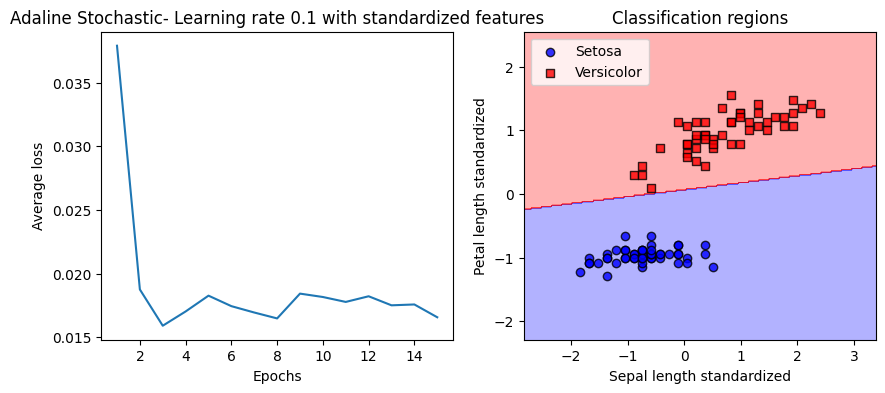

In [8]:
X_std = np.copy(X)
X_std[:,0] = (X[:,0] - X[:,0].mean())/X[:,0].std()
X_std[:,1] = (X[:,1] - X[:,1].mean())/X[:,1].std()

my_adaline_stochastic = AdalineSGD(eta=0.1, epochs=15)
my_adaline_stochastic.fit(X_std,y)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
ax[0].plot(range(1,len(my_adaline_stochastic.losses_)+1), my_adaline_stochastic.losses_)
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Average loss")
ax[0].set_title("Adaline Stochastic- Learning rate 0.1 with standardized features")

plot_decision_regions(X=X_std, y=y, algorithm=my_adaline_stochastic)
ax[1].set_xlabel("Sepal length standardized")
ax[1].set_ylabel("Petal length standardized")
ax[1].legend(loc="upper left")
ax[1].set_title("Classification regions")
plt.show()